# Import Relevent Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os

In [2]:
cwd = os.getcwd()
pd.set_option('display.max_rows',100000)

# Importing the data 

In [3]:
df = pd.read_csv('All practice jupyter notebooks/suicide_rate.csv/master.csv')
df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [7]:
df.rename(columns = {' gdp_for_year ($) ':'gdp_year'}, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9   gdp_year            27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [8]:
# dropping country_year column
df.drop('country-year',axis = 1,inplace = True)

## Visualization of Data

#### 1. Total number of Suicides Country-wise

In [9]:
suicides_per_country = df.groupby('country').sum('suicides_no').reset_index().sort_values('suicides_no',ascending = False)
suicides_per_country = suicides_per_country[['country','suicides_no']]
suicides_per_country.head()

,country,suicides_no
75,Russian Federation,1209742
98,United States,1034013
46,Japan,806902
33,France,329127
95,Ukraine,319950


C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[Text(0, 0, 'Russian Federation'),
 Text(1, 0, 'United States'),
 Text(2, 0, 'Japan'),
 Text(3, 0, 'France'),
 Text(4, 0, 'Ukraine'),
 Text(5, 0, 'Germany'),
 Text(6, 0, 'Republic of Korea'),
 Text(7, 0, 'Brazil'),
 Text(8, 0, 'Poland'),
 Text(9, 0, 'United Kingdom')]

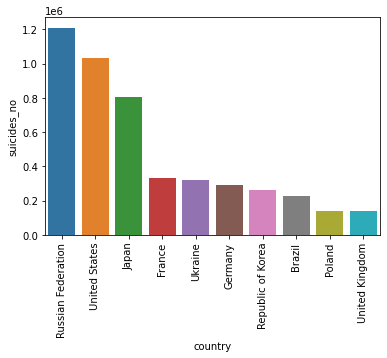

In [7]:
barplot_1 = sns.barplot('country','suicides_no',data = suicides_per_country[:10])
barplot_1.set_xticklabels(suicides_per_country['country'][:10], rotation=90)

#### Observation:-
####    1. Most number of suicides occur in Russian Federation followed by United States
####    2. It can be misleading as they also have bigger/larger Population.
####    3. To Further Analyze we can find the suicide_no/country population

In [8]:
# Finding total suicide rate per countries population
total_suicide = df.groupby(['country','year'])['suicides_no'].sum()
total_popu = df.groupby(['country','year'])['population'].sum()
percentage_suicide = total_suicide/total_popu
percen = percentage_suicide.reset_index().rename(columns = {0:'percen'})
percen = percen.groupby('country')['percen'].mean().reset_index().sort_values('percen',ascending = False)

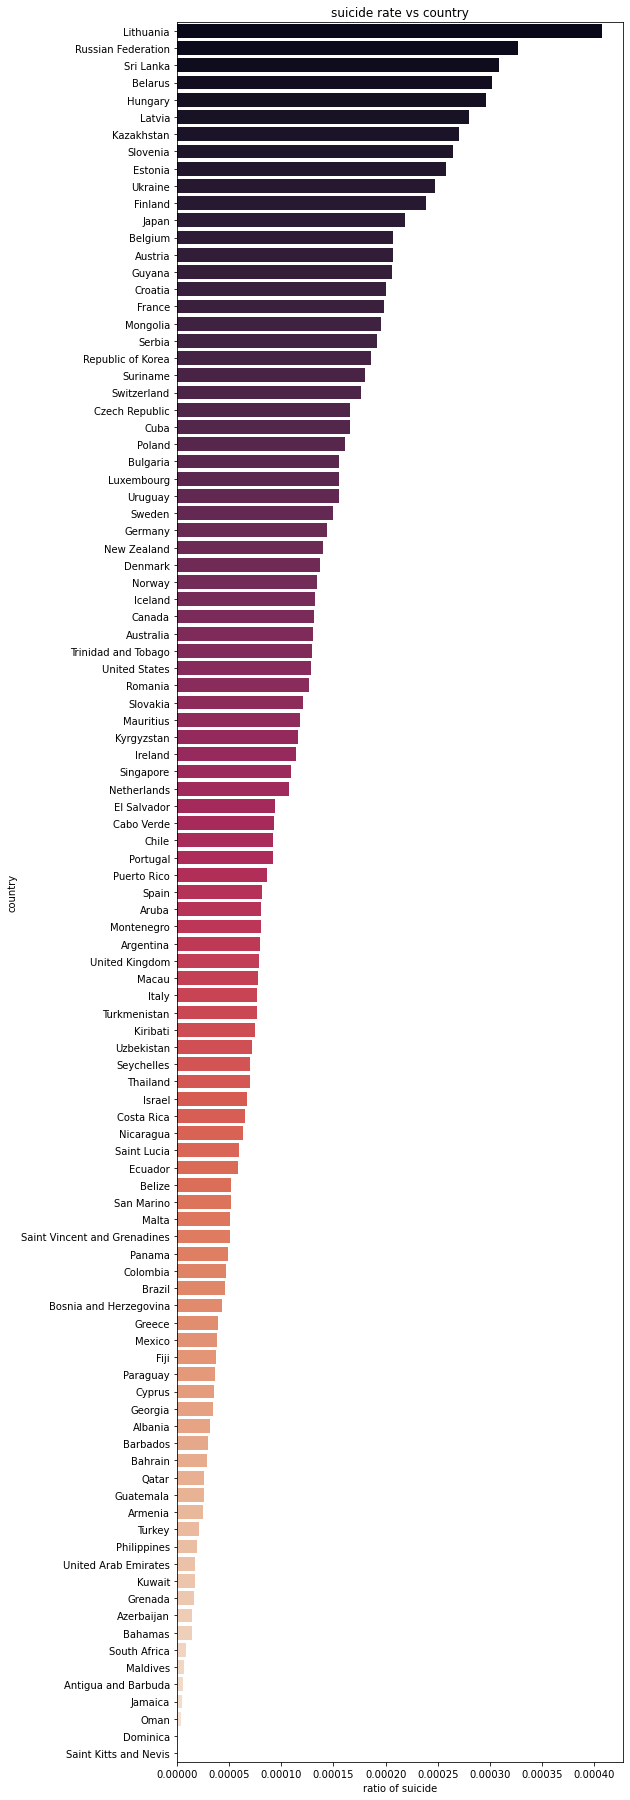

In [9]:
plt.figure(figsize=(8,32))
sns.barplot(x=percen['percen'],y=percen['country'], palette="rocket")
plt.xlabel("ratio of suicide")
plt.ylabel("country")
plt.title("suicide rate vs country")
plt.show()

## suicides per generations 

In [11]:
suicides_per_gen = df.groupby('generation').sum('suicides_no').reset_index().sort_values('suicides_no',ascending = False)
suicides_per_gen = suicides_per_gen[['generation','suicides_no']]
suicides_per_gen.head()

,generation,suicides_no
0,Boomers,2284498
5,Silent,1781744
2,Generation X,1532804
4,Millenials,623459
1,G.I. Generation,510009


C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[Text(0, 0, 'Boomers'),
 Text(1, 0, 'Silent'),
 Text(2, 0, 'Generation X'),
 Text(3, 0, 'Millenials'),
 Text(4, 0, 'G.I. Generation'),
 Text(5, 0, 'Generation Z')]

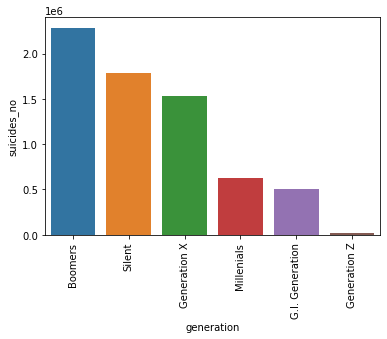

In [12]:
barplot_2 = sns.barplot('generation','suicides_no',data = suicides_per_gen[:10])
barplot_2.set_xticklabels(suicides_per_gen['generation'][:10], rotation=90)

### Observation:-
####   Boomers have the highest suicide number, followed by silent generation and  generation x and millenials

In [16]:
suicides_by_age_group = df.groupby('age').sum('suicide_no').reset_index().sort_values('suicides_no',ascending = 0)
suicides_by_age_group = suicides_by_age_group[['age','suicides_no']]
suicides_by_age_group

,age,suicides_no
2,35-54 years,2452141
4,55-74 years,1658443
1,25-34 years,1123912
0,15-24 years,808542
5,75+ years,653118
3,5-14 years,52264


C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


[Text(0, 0, '35-54 years'),
 Text(1, 0, '55-74 years'),
 Text(2, 0, '25-34 years'),
 Text(3, 0, '15-24 years'),
 Text(4, 0, '75+ years'),
 Text(5, 0, '5-14 years')]

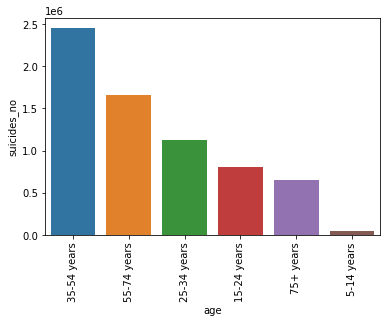

In [17]:
barplot_3 = sns.barplot('age','suicides_no',data = suicides_by_age_group[:10])
barplot_3.set_xticklabels(suicides_by_age_group['age'][:10], rotation=90)

C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


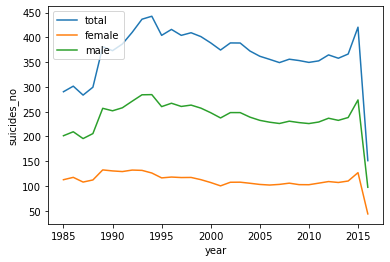

In [18]:
df_men = df[df.sex == "male"]
df_women = df[df.sex == "female"]
sns.lineplot(df_men.year, df.suicides_no, ci = None)
sns.lineplot(df_women.year, df.suicides_no, ci = None)
sns.lineplot(df.year, df.suicides_no, ci = None)
plt.legend(['total','female', 'male'])
plt.show()

In [19]:
df_year = df.groupby('year').sum('suicides_no').reset_index()
df_year = df_year[['year','suicides_no']]

df_men = df_men.groupby('year').sum('suicides_no').reset_index()
df_men = df_men[['year','suicides_no']]

df_women = df_women.groupby('year').sum('suicides_no').reset_index()
df_women = df_women[['year','suicides_no']]

C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


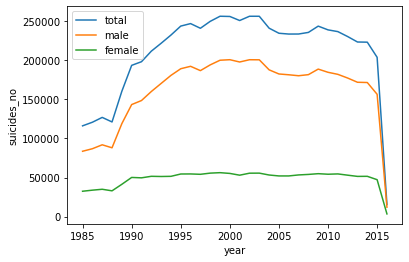

In [20]:
sns.lineplot('year','suicides_no',data=df_year,ci = None)
sns.lineplot('year','suicides_no',data=df_men,ci = None)
sns.lineplot('year','suicides_no',data=df_women,ci = None)
plt.legend(['total','male', 'female'])
plt.show()

In [25]:
df['gdp_year'] = df['gdp_year'].str.replace(',','').astype('int64')

AttributeError: Can only use .str accessor with string values!

C:\Users\balra\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


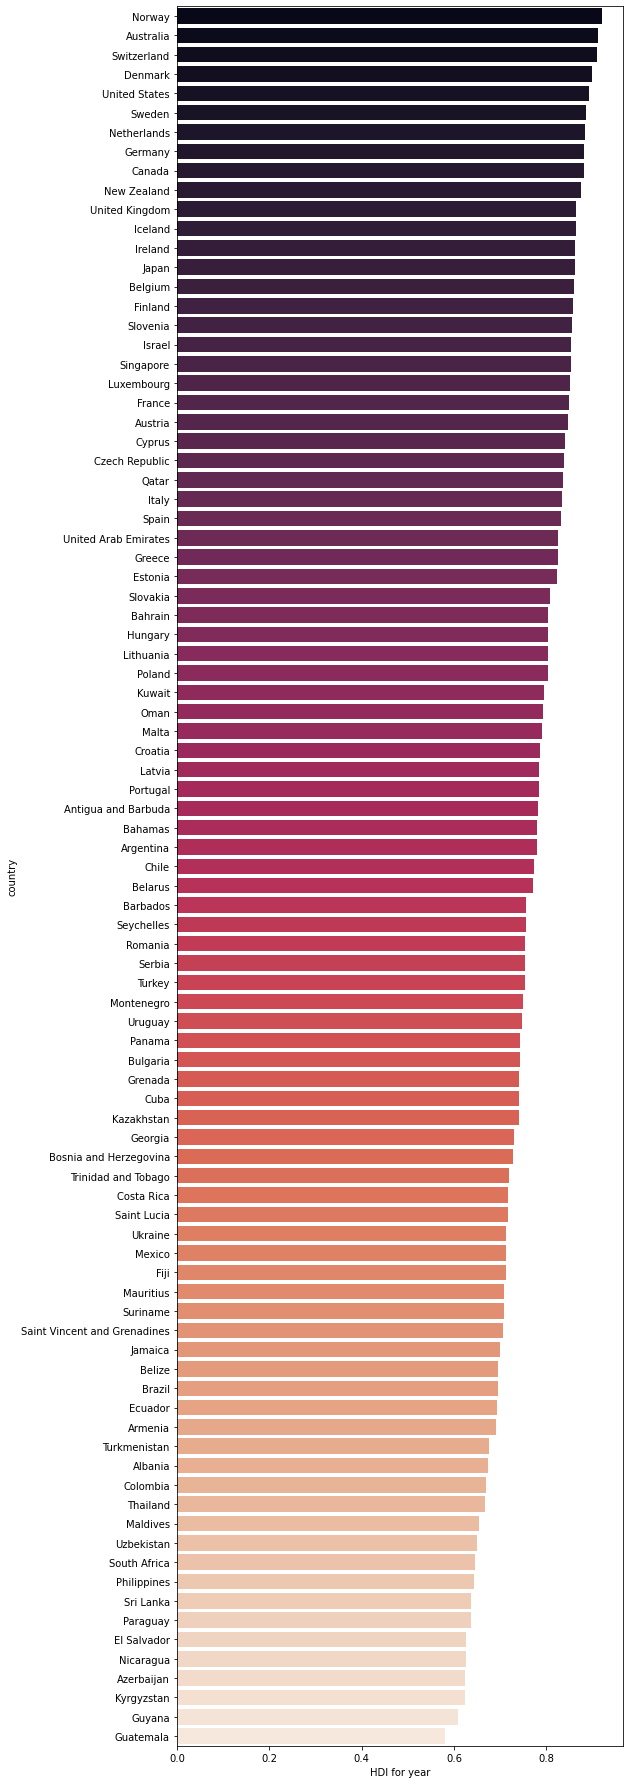

In [26]:
df_new = df[~df['HDI for year'].isnull()]
df_new = df_new.groupby('country')['HDI for year'].mean().reset_index().sort_values('HDI for year',ascending = False)
plt.figure(figsize =(8,32))
sns.barplot(df_new['HDI for year'],df_new['country'],palette = 'rocket')
plt.show()

In [ ]:
from sklearn